# IAQ Data Analysis

This notebook performs a comprehensive analysis of the Indoor Air Quality (IAQ) dataset from Baqubah Teaching Hospital. 
The analysis includes data cleaning, preprocessing, exploratory data analysis (EDA), and various visualizations.

## 1. Setup and Data Loading

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset
file_path = 'IAQ Baqubah Teaching Hospital .csv'
try:
    df = pd.read_csv(file_path)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: File '{file_path}' not found. Please check the file path.")

# Display the first few rows
df.head()

Data loaded successfully.


,CO2,TVOC,PM10,PM2.5,eCO2,CO,Air Quality,LDR,O3,Temp,Hum,ts
0,425.000000,4.0,5.190,0.320000,588.0,357.0,42.000000,962.0,522.000000,26.300000,41.700000,5/22/2024 12:13
1,419.500000,26.5,5.240,0.260000,590.0,360.5,41.500000,962.0,521.500000,26.200000,41.650000,5/22/2024 12:14
2,420.666667,19.0,5.760,0.266667,556.0,360.0,41.333333,962.0,523.666667,26.133333,41.666667,5/22/2024 12:15
3,424.000000,15.5,5.765,0.292500,536.0,360.5,40.500000,962.0,524.750000,26.100000,41.650000,5/22/2024 12:16
4,419.200000,22.2,6.946,0.342000,666.5,357.2,40.400000,961.8,526.200000,25.920000,41.980000,5/22/2024 12:50


In [12]:
# Basic dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523524 entries, 0 to 523523
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CO2          523524 non-null  float64
 1   TVOC         523524 non-null  float64
 2   PM10         523524 non-null  float64
 3   PM2.5        523524 non-null  float64
 4   eCO2         203159 non-null  float64
 5   CO           523524 non-null  float64
 6   Air Quality  523524 non-null  float64
 7   LDR          523524 non-null  float64
 8   O3           523524 non-null  float64
 9   Temp         523524 non-null  float64
 10  Hum          523524 non-null  float64
 11  ts           523524 non-null  object 
dtypes: float64(11), object(1)
memory usage: 47.9+ MB


In [13]:
# Summary statistics
df.describe()

,CO2,TVOC,PM10,PM2.5,eCO2,CO,Air Quality,LDR,O3,Temp,Hum
count,523524.000000,523524.000000,523524.000000,523524.000000,203159.000000,523524.000000,523524.000000,523524.000000,523524.000000,523524.000000,523524.000000
mean,512.281274,50.626842,782.512225,102.466800,440.613554,409.098120,117.580437,892.647055,626.467808,26.378307,44.792178
std,185.873552,16.179725,362.372013,52.308006,113.883309,118.291014,54.061087,173.132083,61.982747,2.735585,6.022637
min,383.000000,4.000000,4.330000,0.000000,400.000000,115.800000,30.000000,14.000000,456.000000,19.360000,24.500000
25%,422.400000,46.200000,600.071500,65.106000,400.000000,326.400000,66.200000,917.600000,586.600000,24.380000,41.580000
50%,437.000000,49.000000,746.638000,111.936000,402.000000,409.600000,125.800000,932.000000,625.600000,26.000000,44.940000
75%,448.800000,54.600000,982.688000,136.362500,409.000000,489.800000,163.800000,945.800000,668.400000,28.100000,48.360000
max,964.000000,104.000000,1873.492000,283.356000,5000.000000,727.800000,295.800000,982.800000,806.000000,33.700000,59.280000


## 2. Data Cleaning

In [14]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values[missing_values > 0])

# Drop eCO2 column because the column has more tan 50% missing values
df_clean = df.drop(columns=['eCO2'])

# Handle any other remaining missing values with forward fill (time series data)
# We still prioritize dropping rows with missing timestamps if any (though ffill might handle them if not at start)
if 'ts' in df_clean.columns:
    df_clean = df_clean.dropna(subset=['ts'])

df_clean = df_clean.ffill().bfill()

print(f"\nShape after data handling: {df_clean.shape}")
print("Remaining missing values:\n", df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing Values:
 eCO2    320365
dtype: int64

Shape after data handling: (523524, 11)
Remaining missing values:
 Series([], dtype: int64)


In [15]:
# Check for duplicates
duplicates = df_clean.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Remove duplicates if any
df_clean = df_clean.drop_duplicates()
print(f"Shape after removing duplicates: {df_clean.shape}")

Number of duplicate rows: 0
Shape after removing duplicates: (523524, 11)


## 3. Data Preprocessing

In [16]:
# Convert 'ts' column to datetime objects
df_clean['ts'] = pd.to_datetime(df_clean['ts'])

# Sort by timestamp
df_clean = df_clean.sort_values('ts')

# Extract temporal features
df_clean['Hour'] = df_clean['ts'].dt.hour
df_clean['Day'] = df_clean['ts'].dt.day
df_clean['Month'] = df_clean['ts'].dt.month
df_clean['DayOfWeek'] = df_clean['ts'].dt.day_name()

df_clean.head()

,CO2,TVOC,PM10,PM2.5,CO,Air Quality,LDR,O3,Temp,Hum,ts,Hour,Day,Month,DayOfWeek
0,425.000000,4.0,5.190,0.320000,357.0,42.000000,962.0,522.000000,26.300000,41.700000,2024-05-22 12:13:00,12,22,5,Wednesday
1,419.500000,26.5,5.240,0.260000,360.5,41.500000,962.0,521.500000,26.200000,41.650000,2024-05-22 12:14:00,12,22,5,Wednesday
2,420.666667,19.0,5.760,0.266667,360.0,41.333333,962.0,523.666667,26.133333,41.666667,2024-05-22 12:15:00,12,22,5,Wednesday
3,424.000000,15.5,5.765,0.292500,360.5,40.500000,962.0,524.750000,26.100000,41.650000,2024-05-22 12:16:00,12,22,5,Wednesday
4,419.200000,22.2,6.946,0.342000,357.2,40.400000,961.8,526.200000,25.920000,41.980000,2024-05-22 12:50:00,12,22,5,Wednesday


## 4. Exploratory Data Analysis (EDA)

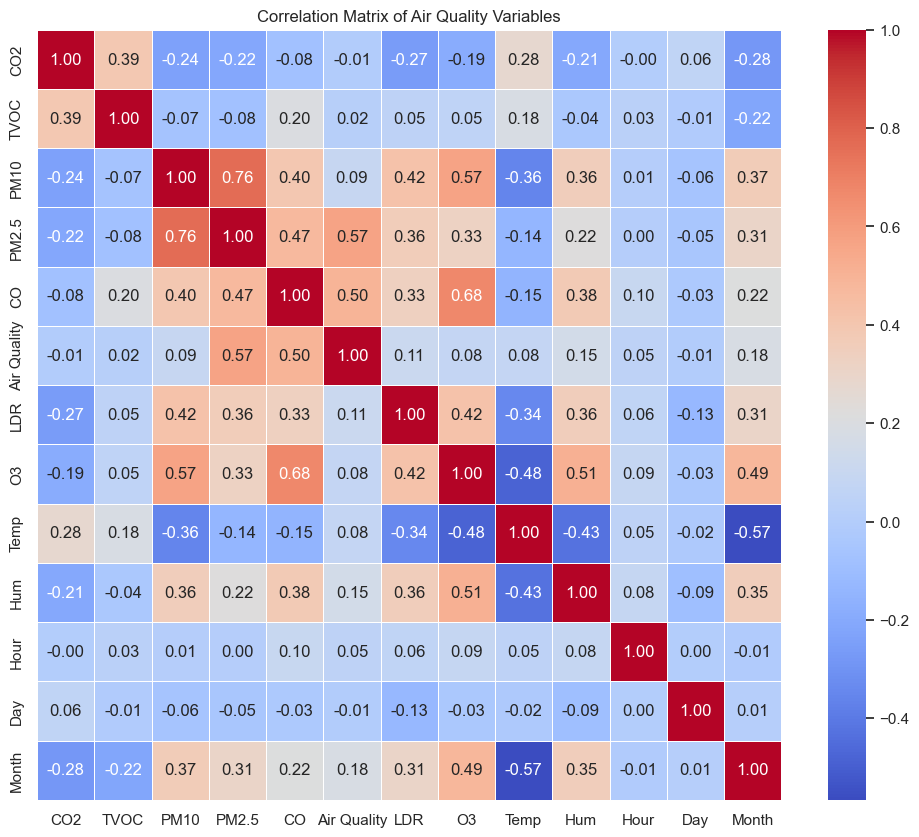

In [17]:
# Correlation Matrix
# Select numeric columns for correlation
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Air Quality Variables')
plt.show()

## 5. Data Visualizations

### 5.1 Univariate Analysis

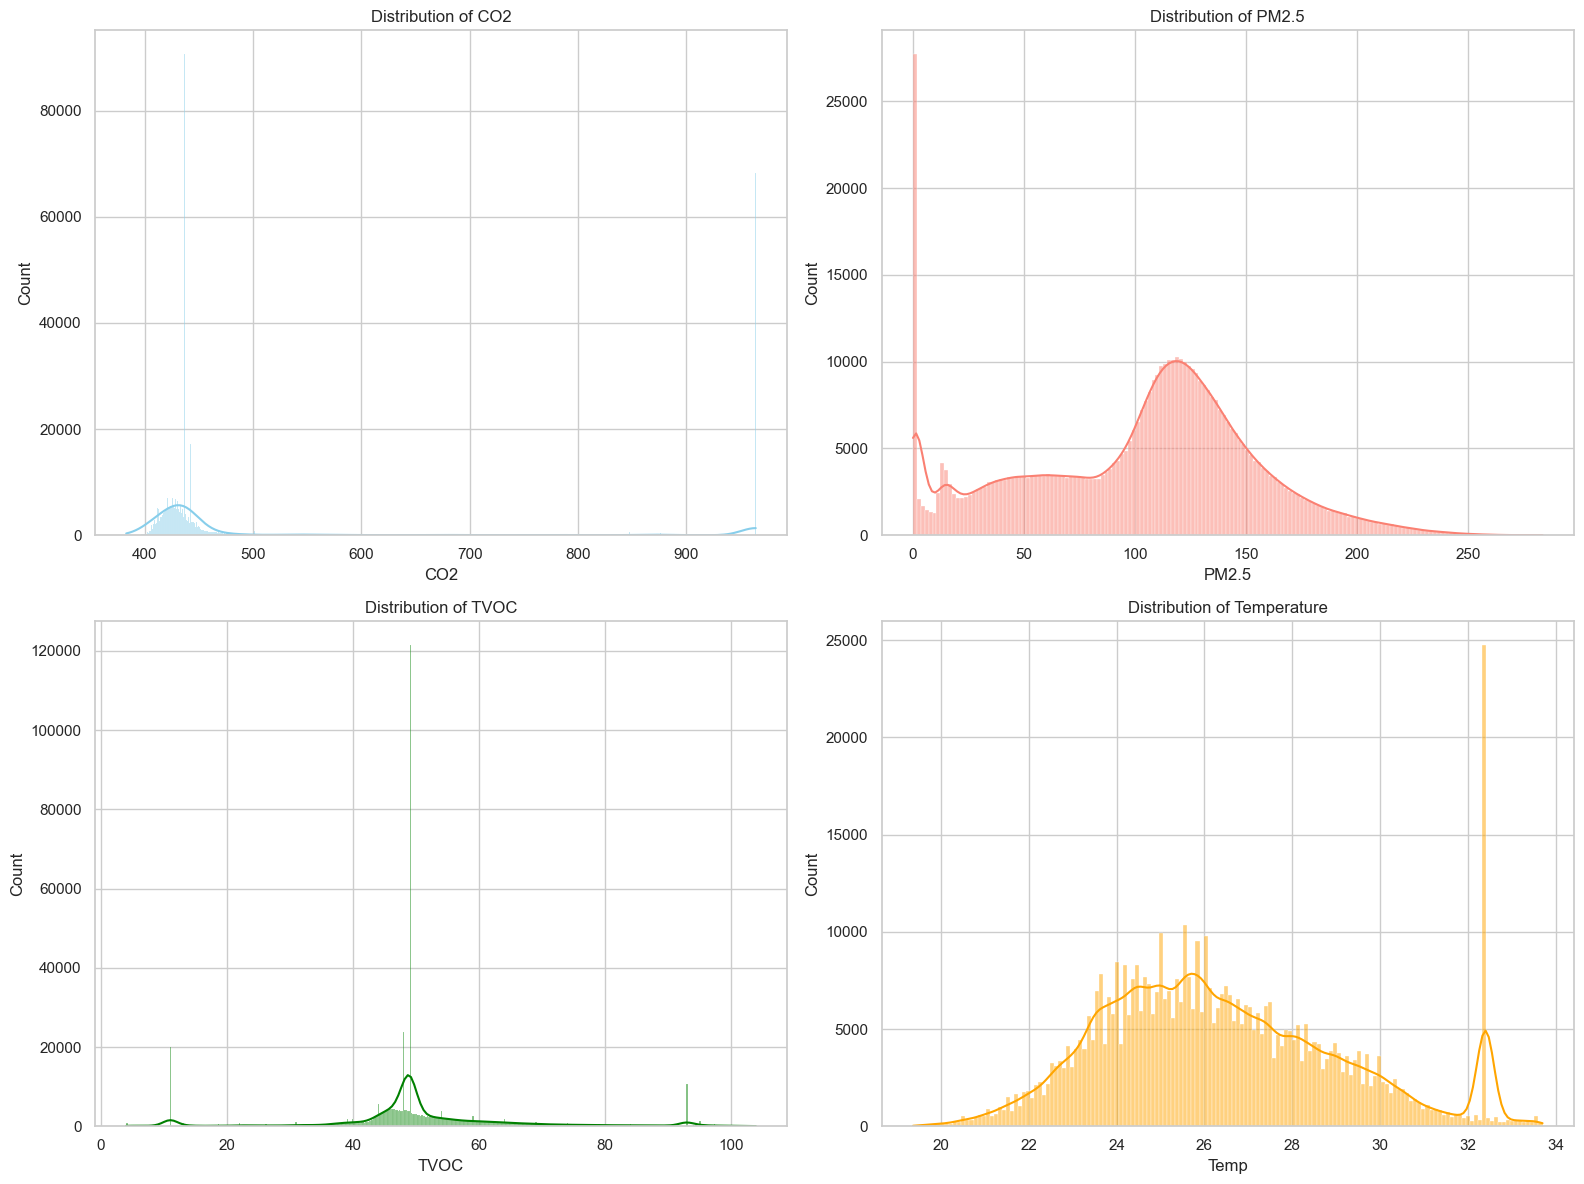

In [18]:
# Distribution of Key Pollutants
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df_clean['CO2'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of CO2')

sns.histplot(df_clean['PM2.5'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Distribution of PM2.5')

sns.histplot(df_clean['TVOC'], kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Distribution of TVOC')

sns.histplot(df_clean['Temp'], kde=True, ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Distribution of Temperature')

plt.tight_layout()
plt.show()

### 5.2 Bivariate Analysis

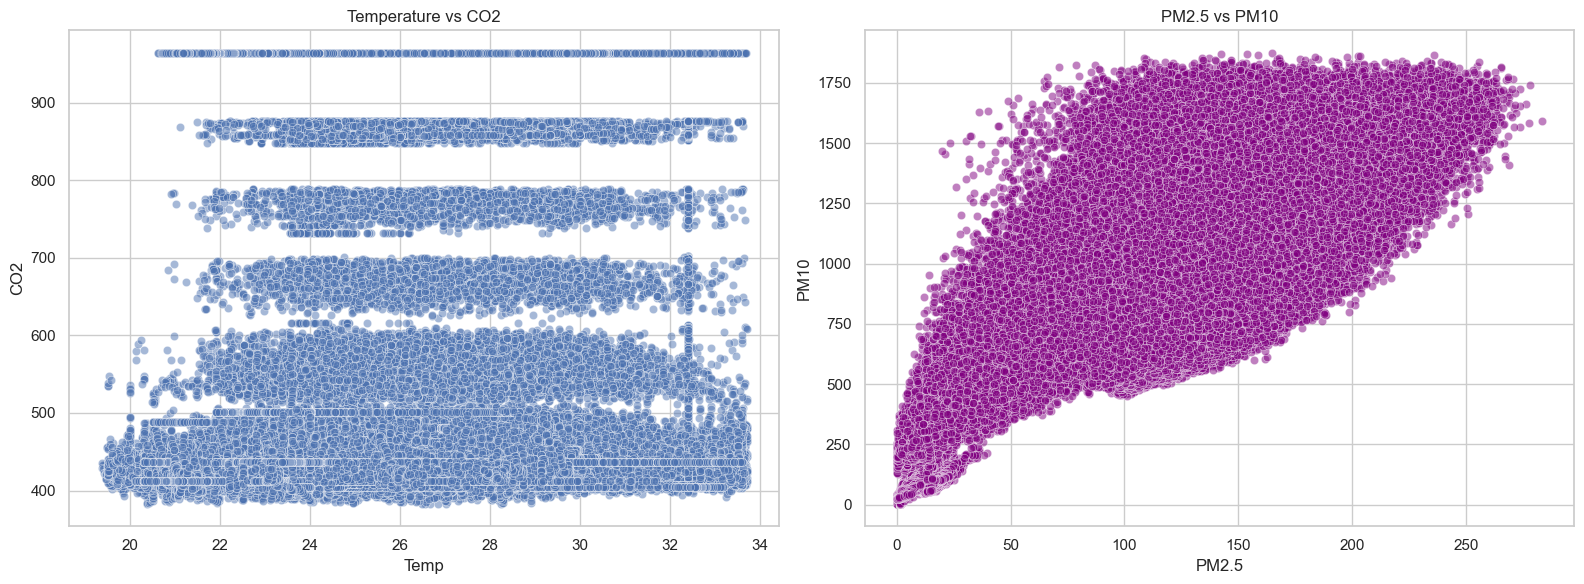

In [19]:
# Scatter plots to explore relationships
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Temperature vs CO2
sns.scatterplot(data=df_clean, x='Temp', y='CO2', alpha=0.5, ax=axes[0])
axes[0].set_title('Temperature vs CO2')

# PM2.5 vs PM10
sns.scatterplot(data=df_clean, x='PM2.5', y='PM10', alpha=0.5, color='purple', ax=axes[1])
axes[1].set_title('PM2.5 vs PM10')

plt.tight_layout()
plt.show()

### 5.3 Temporal Analysis

C:\Users\Dell7480\AppData\Local\Temp\ipykernel_12876\3897547600.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_clean.set_index('ts').resample('H').mean(numeric_only=True).reset_index()


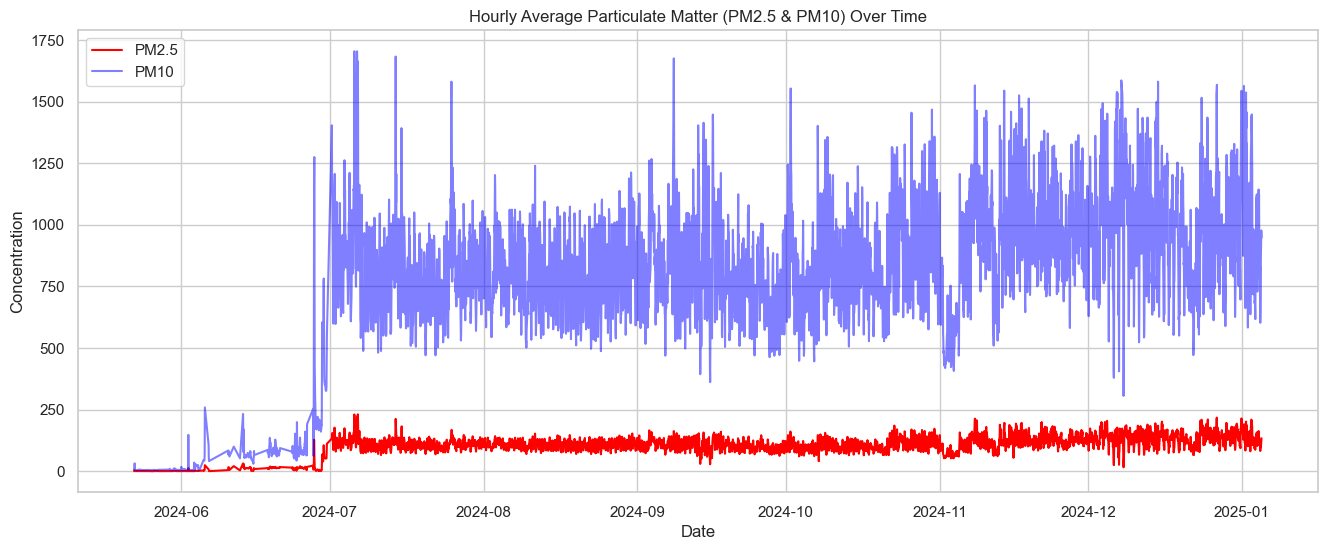

In [20]:
# Resample data to hourly averages for cleaner time series plots
df_hourly = df_clean.set_index('ts').resample('H').mean(numeric_only=True).reset_index()

plt.figure(figsize=(16, 6))
sns.lineplot(data=df_hourly, x='ts', y='PM2.5', label='PM2.5', color='red')
sns.lineplot(data=df_hourly, x='ts', y='PM10', label='PM10', color='blue', alpha=0.5)
plt.title('Hourly Average Particulate Matter (PM2.5 & PM10) Over Time')
plt.xlabel('Date')
plt.ylabel('Concentration')
plt.legend()
plt.show()

### 5.4 Composition / Categorical Analysis

C:\Users\Dell7480\AppData\Local\Temp\ipykernel_12876\455570235.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_avg, x='Hour', y='CO2', palette='viridis')


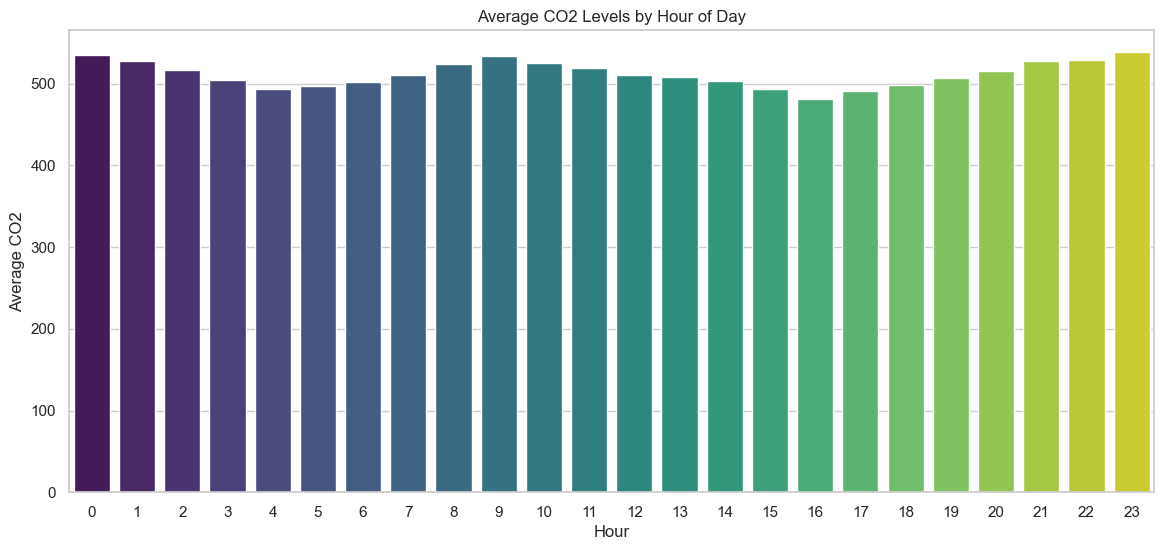

In [21]:
# Average CO2 by Hour of Day
hourly_avg = df_clean.groupby('Hour')[['CO2', 'TVOC', 'PM2.5']].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=hourly_avg, x='Hour', y='CO2', palette='viridis')
plt.title('Average CO2 Levels by Hour of Day')
plt.ylabel('Average CO2')
plt.show()

C:\Users\Dell7480\AppData\Local\Temp\ipykernel_12876\451020077.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily_avg, x='DayOfWeek', y='PM2.5', palette='magma')


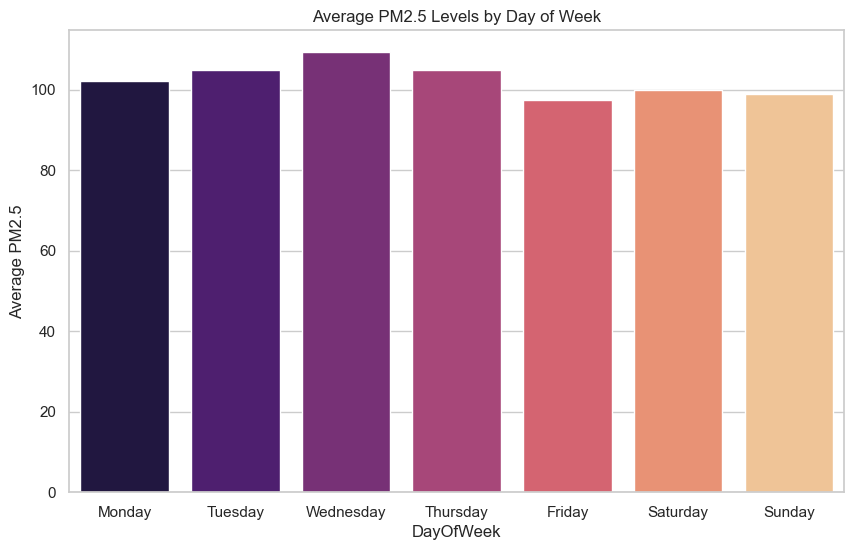

In [22]:
# Average PM2.5 by Day of Week
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg = df_clean.groupby('DayOfWeek')['PM2.5'].mean().reindex(order).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=daily_avg, x='DayOfWeek', y='PM2.5', palette='magma')
plt.title('Average PM2.5 Levels by Day of Week')
plt.ylabel('Average PM2.5')
plt.show()

## 6. Advanced EDA & Insights (PM2.5 Focus)
This section focuses specifically on understanding the factors influencing PM2.5 levels to aid in model development.

C:\Users\Dell7480\AppData\Local\Temp\ipykernel_12876\584829559.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')


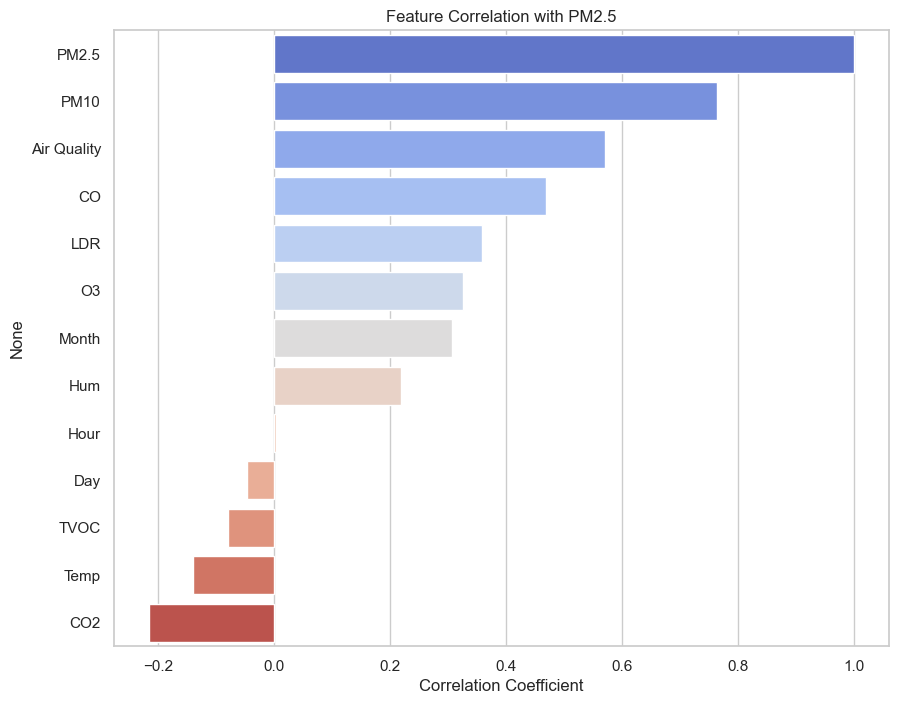

In [23]:
# Correlation with Target (PM2.5)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
target_corr = df_clean[numeric_cols].corrwith(df_clean['PM2.5']).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')
plt.title('Feature Correlation with PM2.5')
plt.xlabel('Correlation Coefficient')
plt.show()

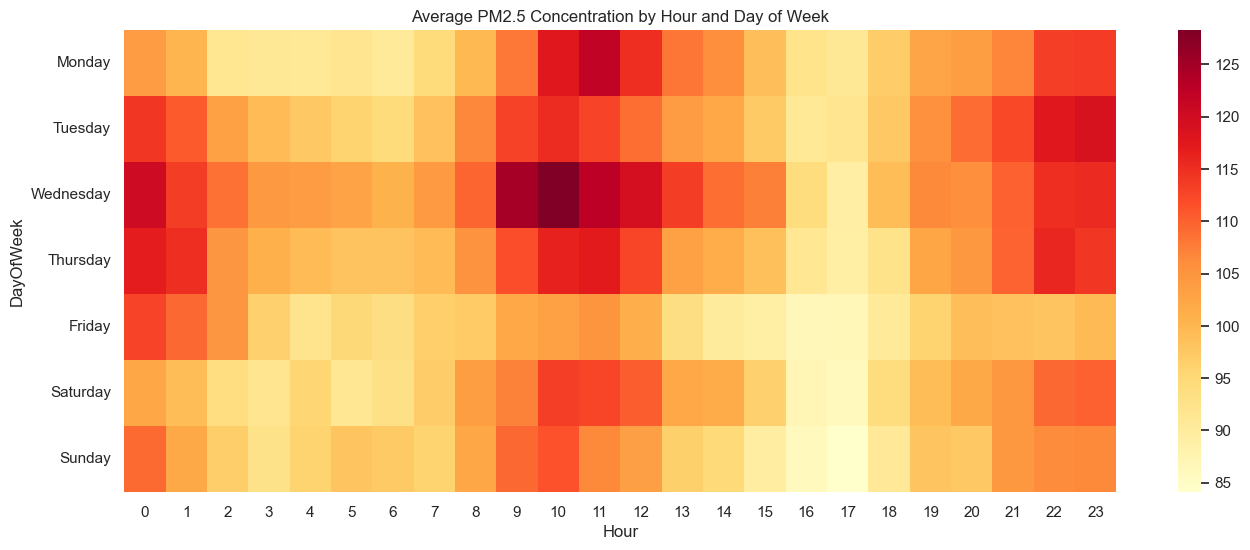

In [24]:
# PM2.5 Heatmap: Hour vs Day of Week
# Re-using 'order' from previous cell if available, otherwise defining it
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_table = df_clean.pivot_table(values='PM2.5', index='DayOfWeek', columns='Hour', aggfunc='mean').reindex(order)

plt.figure(figsize=(16, 6))
sns.heatmap(pivot_table, cmap='YlOrRd', annot=False)
plt.title('Average PM2.5 Concentration by Hour and Day of Week')
plt.show()

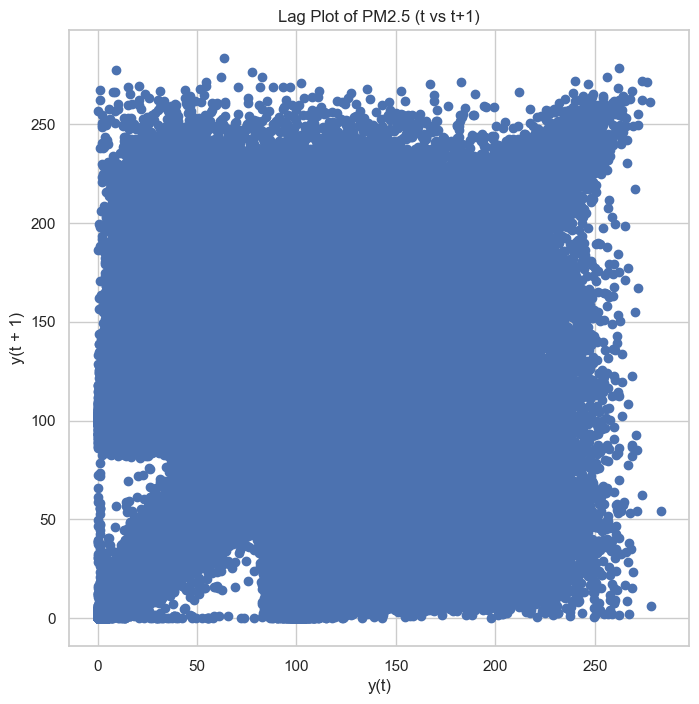

In [25]:
# Lag Plot for PM2.5 (Autocorrelation)
from pandas.plotting import lag_plot

plt.figure(figsize=(8, 8))
lag_plot(df_clean['PM2.5'])
plt.title('Lag Plot of PM2.5 (t vs t+1)')
plt.show()

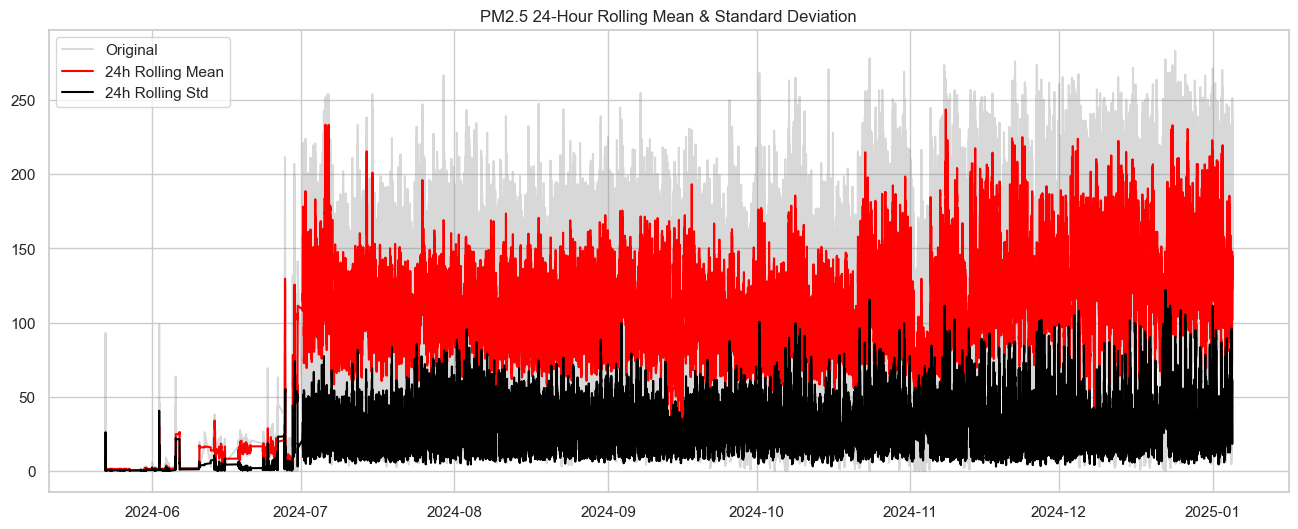

In [26]:
# Rolling Mean & Standard Deviation (24-hour window)
rolling_mean = df_clean.set_index('ts')['PM2.5'].rolling(window=24).mean()
rolling_std = df_clean.set_index('ts')['PM2.5'].rolling(window=24).std()

plt.figure(figsize=(16, 6))
plt.plot(df_clean['ts'], df_clean['PM2.5'], label='Original', alpha=0.3, color='gray')
plt.plot(rolling_mean.index, rolling_mean, label='24h Rolling Mean', color='red')
plt.plot(rolling_std.index, rolling_std, label='24h Rolling Std', color='black')
plt.title('PM2.5 24-Hour Rolling Mean & Standard Deviation')
plt.legend()
plt.show()

c:\Users\Dell7480\anaconda3\envs\torch_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


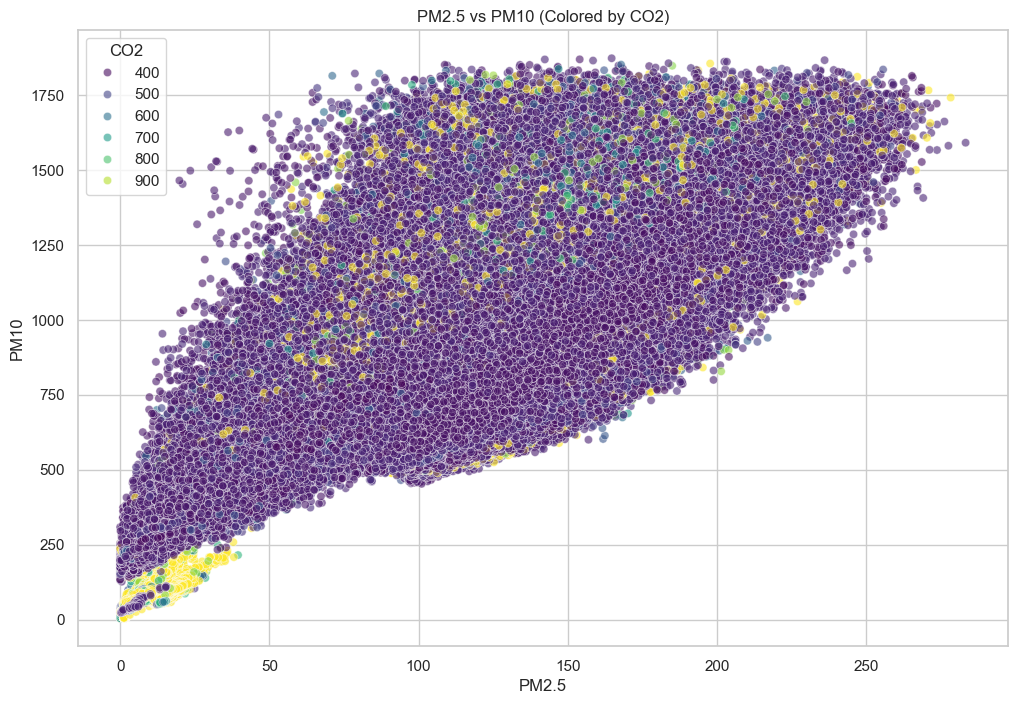

In [27]:
# Multivariate Analysis: PM2.5 vs PM10 colored by CO2
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_clean, x='PM2.5', y='PM10', hue='CO2', palette='viridis', alpha=0.6)
plt.title('PM2.5 vs PM10 (Colored by CO2)')
plt.show()